<a href="https://colab.research.google.com/github/WuilderOsio1198/Senalesysistemas/blob/main/Tarea_Red_Electrica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Tarea en clase
Estudiante:Wuilder Joafran Osio Tandioy

## Análisis de redes eléctricas con elementos Pasivos


![Filtro pasa bajas analógico de segundo orden](https://github.com/amalvarezme/SenalesSistemas/blob/master/4_Transformada_Laplace/lowpass.png?raw=1)


- Se asume que no se almacena energía en el condensador ni en el inductor para $t<0$. Además, se supone que $x(t)=0$ para $t<0$.

- Por lo tanto, $y(t)=0$ y $\frac{d y(t)}{dt}=0$ para $ t<0$. Para ilustrar, se utilizan los valores de $L=0.18$, $R=1000$, $C=0.00012$ como los parámetros de la red eléctrica.

##1.Plantear EDO
\begin{equation}
C L \frac{d^2 Vc(t)}{dt^2} + C R \frac{d Vc(t)}{dt} + Vc(t) = Vi(t)
\end{equation}


In [31]:
%matplotlib inline
import sympy as sym
sym.init_printing()
#se definen variables simbólicas y EDO
t, L, R, C = sym.symbols('t L R C', real=True)
Vi = sym.Function('Vi')(t)
Vc = sym.Function('Vc')(t)

ode = sym.Eq(L*C*Vc.diff(t, 2) + R*C*Vc.diff(t) + Vc, Vi)
ode

     2                                        
    d                d                        
C⋅L⋅───(Vc(t)) + C⋅R⋅──(Vc(t)) + Vc(t) = Vi(t)
      2              dt                       
    dt                                        

In [32]:
RLC = {R: 1000, L: sym.Rational('0.18'), C: sym.Rational('0.00012')}  # guardamos los parametros en un diccionario
RLC

{C: 3/25000, L: 9/50, R: 1000}

#Funcion de transferencia
¿Que es diagrama de bode?¿Por que en decibelios?
Es una grafica que representa la respuesta en frecuencia de un sistema, mostrando la magnitud y la fase frente a la frecuencia, generalmente en una escala logaritmica.

Se utilizan decibelios (dB) para la magnitud porque la escala logaritmica permite comprimir un rango muy amplio de valores en un grafico manejable y vizualizar los cambios de ganancia de manera mas clara, especialmente al multiplicar o dividir funciones de transferencia, las cuales se suman en decibelios.

In [33]:
s = sym.symbols('s')
H = sym.Function('H')(s)

H, = sym.solve(ode.subs(Vi, sym.exp(s*t)).subs(Vc, H*sym.exp(s*t)).doit(), H)
H

        1         
──────────────────
     2            
C⋅L⋅s  + C⋅R⋅s + 1

Forma en frecuencia (poniendo s = jw)

In [34]:
#se sustituye s por jm
w = sym.symbols('omega', real=True)

Hjw = H.subs(s, sym.I * w)
Hjw

          1           
──────────────────────
       2              
- C⋅L⋅ω  + ⅈ⋅C⋅R⋅ω + 1

In [50]:
!pip install numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

L = 0.18
C = 0.00012
R = 1000
num = [1]
den = [L*C, R*C, 1]

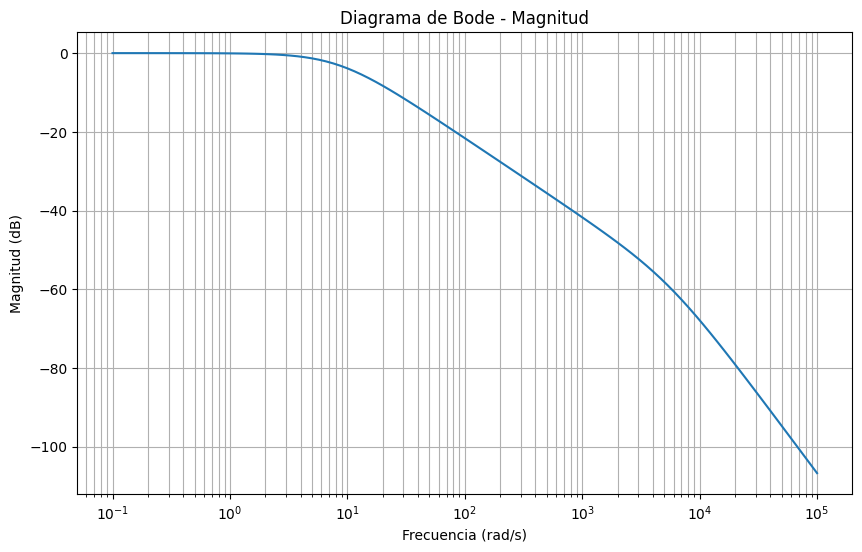

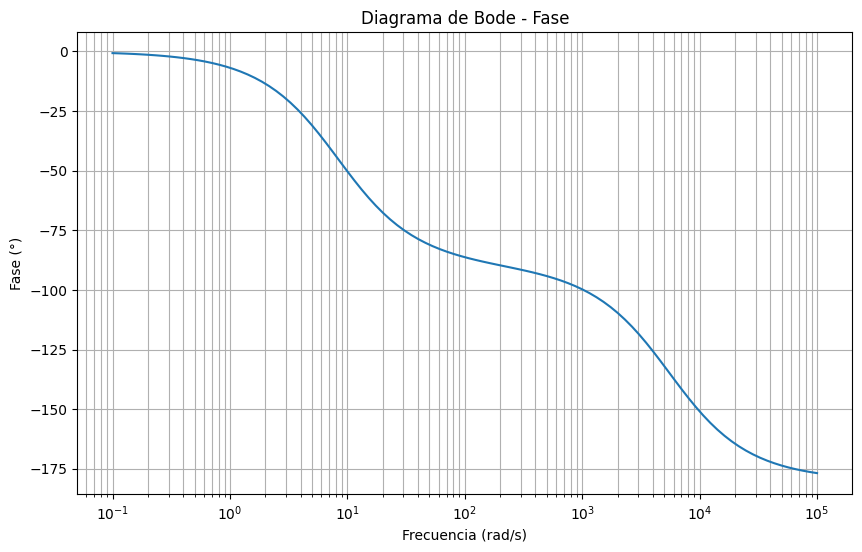

In [51]:

system = signal.TransferFunction(num, den)

w, mag, phase = signal.bode(system)

plt.figure(figsize=(10,6))
plt.semilogx(w, mag)
plt.title("Diagrama de Bode - Magnitud")
plt.xlabel("Frecuencia (rad/s)")
plt.ylabel("Magnitud (dB)")
plt.grid(True, which="both")

plt.figure(figsize=(10,6))
plt.semilogx(w, phase)
plt.title("Diagrama de Bode - Fase")
plt.xlabel("Frecuencia (rad/s)")
plt.ylabel("Fase (°)")
plt.grid(True, which="both")

plt.show()

##Graficamos la magnitud de la funcion de transferencia

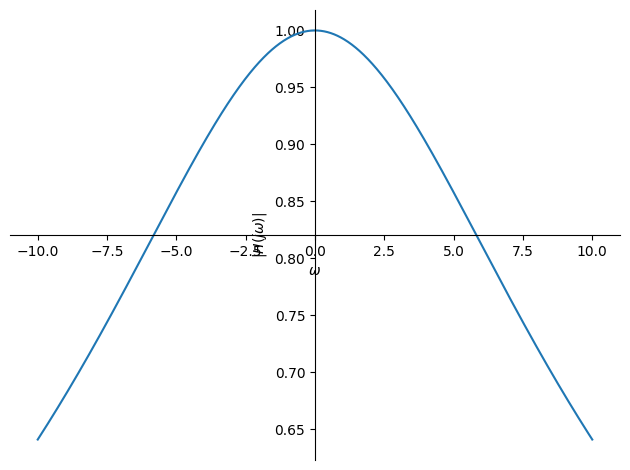

In [35]:
sym.plot(abs(Hjw.subs(RLC)), (w, -10, 10), ylabel=r'$|H(j \omega)|$', xlabel=r'$\omega$');

In [36]:
H2 = sym.integrate(h.rhs.subs(RLC)*sym.exp(-s*t), (t,0,sym.oo), conds='none')
H2.simplify()

         1250000          
──────────────────────────
    2                     
27⋅s  + 150000⋅s + 1250000

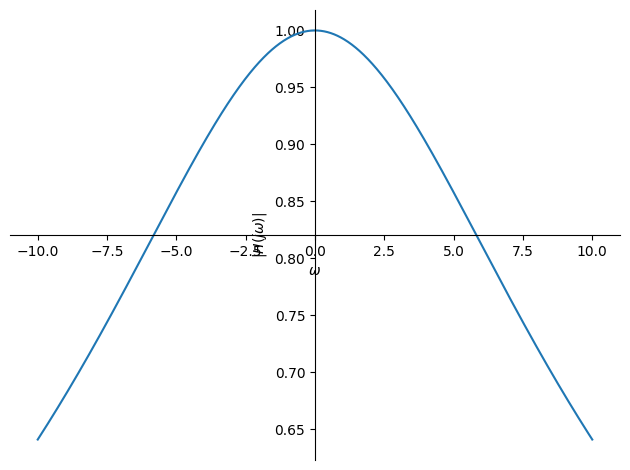

In [37]:
sym.plot(abs(H2.subs(s, sym.I*w)), (w, -10, 10), ylabel=r'$|H(j \omega)|$', xlabel=r'$\omega$');

La fase de la función de transferencia  φ(jω)=arg{H(jω)}  proporciona información sobre la fase agregada a una señal armónica cuando pasa a través del sistema. Se calcula y grafica para los valores específicos de los elementos dados anteriormente.

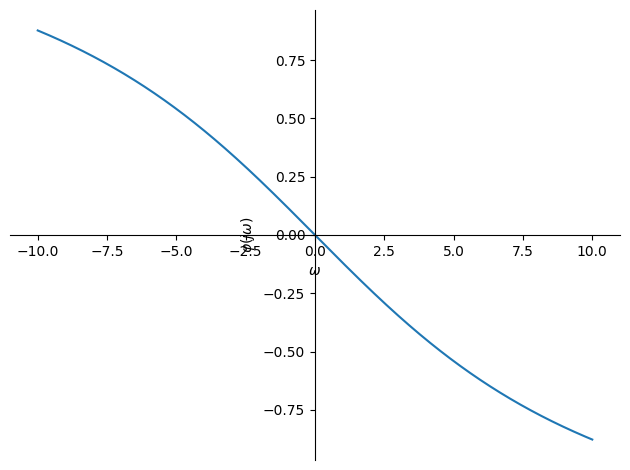

In [38]:
phi = sym.arg(Hjw)
sym.plot(phi.subs(RLC), (w, -10, 10), ylabel=r'$\varphi(j \omega)$', xlabel=r'$\omega$');

### Respuesta al Impulso


La red eléctrica pasiva y la EDO que describen su relación de entrada/salida se pueden interpretar como un SLIT. Por lo tanto, el sistema puede caracterizarse por su respuesta al impulso $h(t)$ que se define como la salida del sistema ante una entrada impulso de Dirac $x(t) = \delta(t)$.

Para el sistema dado, la respuesta al impulso se calcula al resolver la EDO

In [39]:
solution_h = sym.dsolve(ode.subs(Vi, sym.DiracDelta(t)).subs(Vc, sym.Function('h')(t)))
solution_h

                                                                               ↪
             ⎛        ________________⎞          ⎛       ________________⎞     ↪
             ⎜       ╱   ⎛   2      ⎞ ⎟          ⎜      ╱   ⎛   2      ⎞ ⎟     ↪
             ⎜     ╲╱  C⋅⎝C⋅R  - 4⋅L⎠ ⎟          ⎜    ╲╱  C⋅⎝C⋅R  - 4⋅L⎠ ⎟     ↪
           t⋅⎜-R + ───────────────────⎟       -t⋅⎜R + ───────────────────⎟     ↪
             ⎝              C         ⎠          ⎝             C         ⎠     ↪
           ────────────────────────────       ─────────────────────────────    ↪
                       2⋅L                                 2⋅L                 ↪
h(t) = C₁⋅ℯ                             + C₂⋅ℯ                              +  ↪
                                                                               ↪
                                                                               ↪
                                                                               ↪

↪    ⎛        _____________

In [40]:
integration_constants = sym.solve( (solution_h.rhs.limit(t, 0, '-'), solution_h.rhs.diff(t).limit(t, 0, '-')), ['C1', 'C2'] )
integration_constants

{C₁: 0, C₂: 0}

In [41]:
h = solution_h.subs(integration_constants)
h

          ⎛        ________________⎞            ⎛       ________________⎞      
          ⎜       ╱   ⎛   2      ⎞ ⎟            ⎜      ╱   ⎛   2      ⎞ ⎟      
          ⎜     ╲╱  C⋅⎝C⋅R  - 4⋅L⎠ ⎟            ⎜    ╲╱  C⋅⎝C⋅R  - 4⋅L⎠ ⎟      
        t⋅⎜-R + ───────────────────⎟         -t⋅⎜R + ───────────────────⎟      
          ⎝              C         ⎠            ⎝             C         ⎠      
        ────────────────────────────         ─────────────────────────────     
                    2⋅L                                   2⋅L                  
       ℯ                            ⋅θ(t)   ℯ                             ⋅θ(t)
h(t) = ────────────────────────────────── - ───────────────────────────────────
                 ________________                      ________________        
                ╱   ⎛   2      ⎞                      ╱   ⎛   2      ⎞         
              ╲╱  C⋅⎝C⋅R  - 4⋅L⎠                    ╲╱  C⋅⎝C⋅R  - 4⋅L⎠         

Se grafica la respuesta al impulso para los valores $R$, $L$ y $C$ definidos anteriormente en el diccionario

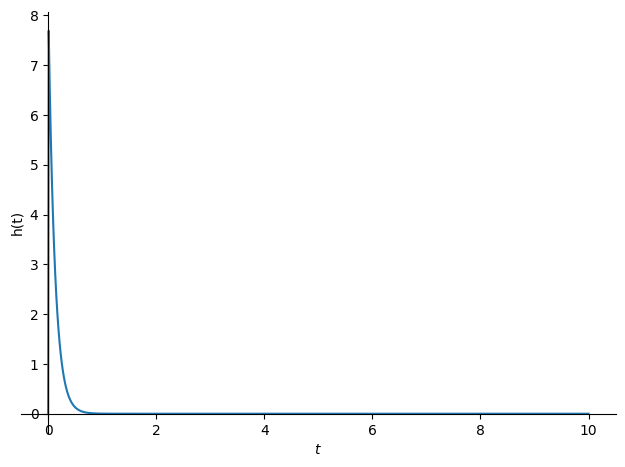

In [42]:
sym.plot(h.rhs.subs(RLC), (t,0,10), ylabel=r'h(t)');

### Respuesta al Escalón

La respuesta al escalón se obtiene al integrar la respuesta al impulso $h(t)$. Para facilitar la ilustración, esto se realiza con los valores de los parámetros definidos anteriormente.

In [43]:
tau = sym.symbols('tau', real=True)

he = sym.integrate(h.rhs.subs(RLC).subs(t,tau), (tau,0,t))
he

          ⎛   25⋅t⋅(-1000 + 20⋅√2485)                     ⎞                  ⎛ ↪
          ⎜   ───────────────────────                     ⎟                  ⎜ ↪
          ⎜              9                                ⎟                  ⎜ ↪
          ⎜9⋅ℯ                                  9         ⎟                  ⎜ ↪
250⋅√2485⋅⎜────────────────────────── - ──────────────────⎟⋅θ(t)   250⋅√2485⋅⎜ ↪
          ⎝    -25000 + 500⋅√2485       -25000 + 500⋅√2485⎠                  ⎝ ↪
──────────────────────────────────────────────────────────────── - ─────────── ↪
                              1491                                             ↪

↪                        -25⋅t⋅(20⋅√2485 + 1000) ⎞     
↪                        ────────────────────────⎟     
↪                                   9            ⎟     
↪         9           9⋅ℯ                        ⎟     
↪ ───────────────── - ───────────────────────────⎟⋅θ(t)
↪ 500⋅√2485 + 25000        500⋅√2485 + 25000     ⎠     
↪ ─────────────

Ahora, se grafica la respuesta al escalón

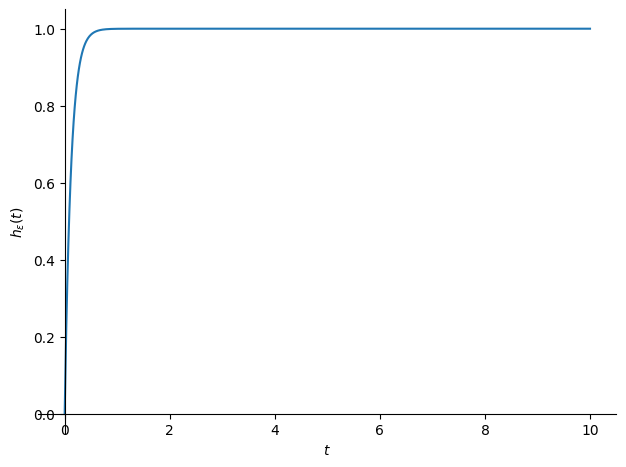

In [44]:
sym.plot(he, (t,0,10), ylabel=r'$h_\epsilon(t)$');

#Diagrama de polos y ceros

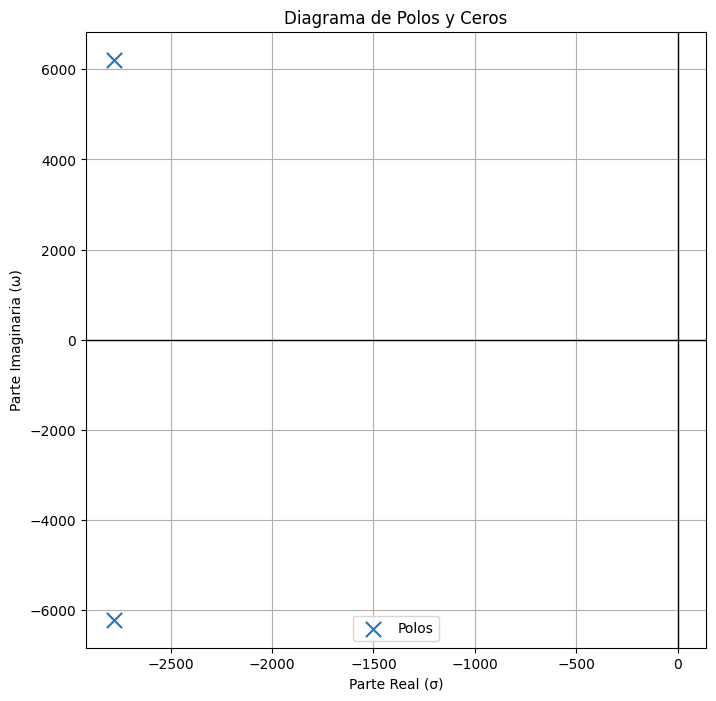

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Polos de el ejercicio
p1 = -2777.7778 + 6211.2999j
p2 = -2777.7778 - 6211.2999j

poles = np.array([p1, p2])

# No hay ceros en este sistema
zeros = np.array([])

plt.figure(figsize=(8,8))

# Graficar polos
plt.scatter(np.real(poles), np.imag(poles), marker='x', s=120, label='Polos')

# Graficar ceros
if len(zeros) > 0:
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', facecolors='none', edgecolors='b', s=120, label='Ceros')

# Ejes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.title("Diagrama de Polos y Ceros")
plt.xlabel("Parte Real (σ)")
plt.ylabel("Parte Imaginaria (ω)")
plt.grid(True, which='both')
plt.legend()
plt.show()

#Respuesta al escalon unitario
$$x(t) = u(t)$$